In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from config import paths

traj = paths.get_trajectory_path
figto = paths.get_figure_path
data = paths.get_data_path

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['font.size'] = 12
%matplotlib inline
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from scipy.spatial import ConvexHull

import os
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from collections import defaultdict
from math import ceil

from tools.custom_hbond_analysis import HydrogenBondAnalysis as HBA
from tools.zeta_order_parameter import ZetaOrderParameter as ZOP
from tools.zeta_cluster_analysis import ZetaClusterAnalysis  as ZCA
from scipy.optimize import linear_sum_assignment
from tools.stress_lammps import stress_universe

# from tools.propensity_field_clusters import (
#     PropensityFieldClusters  as PFC,
#     PropensityFieldTracker   as PFT,
#     finalise_track_arrays,
# )

from tools.propensity_zeta_field_clusters_unwrapped import PropensityFieldClusters as PFC

os.makedirs(figto("pfc_plots"), exist_ok=True)

# os.makedirs(figto("cluster_plots"), exist_ok=True) 

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
u = mda.Universe(traj("tip4p-ice-225K.data"), traj("traj_225_2ns.lammpstrj"), format='LAMMPSDUMP')

/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


In [3]:
print(len(u.trajectory))

10001


Computing ISF: 100%|██████████| 10001/10001 [1:00:28<00:00,  2.76it/s] 


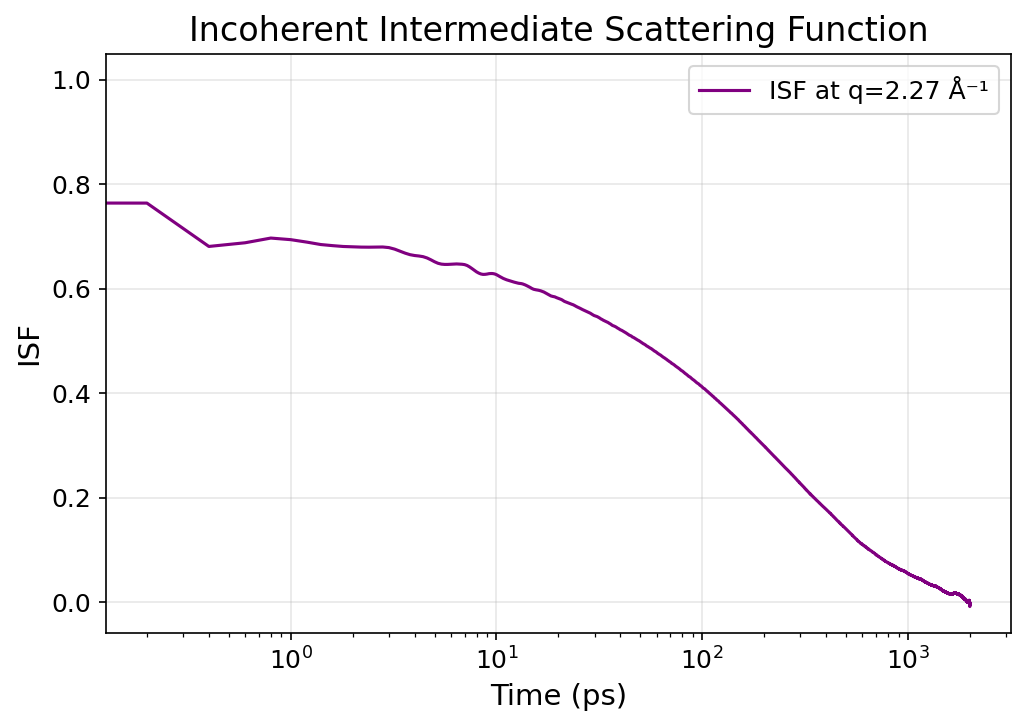

In [4]:
from tools.shear_isf import ISFCalculator as ISF
isf_calculator = ISF(u)

# 定义q矢量（沿z方向的q矢量,垂直于xy平面，不受剪切流影响）
q_magnitude = 2*np.pi / 2.77  # Å⁻¹
q_vectors = np.array([[0, 0, q_magnitude], [q_magnitude, 0, 0], [0, q_magnitude, 0]])

# 计算时间原点平均的ISF
isf = isf_calculator.time_origin_average(q_vectors)
# time_steps = 0.05  # ps
time_steps = 0.2  # ps
times = np.arange(isf.shape[1]) * time_steps

plt.figure(figsize=(7, 5))
plt.plot(times, isf[0], label='ISF at q=2.27 Å⁻¹', color='purple')
plt.xscale('log')
plt.xlabel('Time (ps)', fontsize=14)
plt.ylabel('ISF', fontsize=14)
plt.title('Incoherent Intermediate Scattering Function', fontsize=16)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

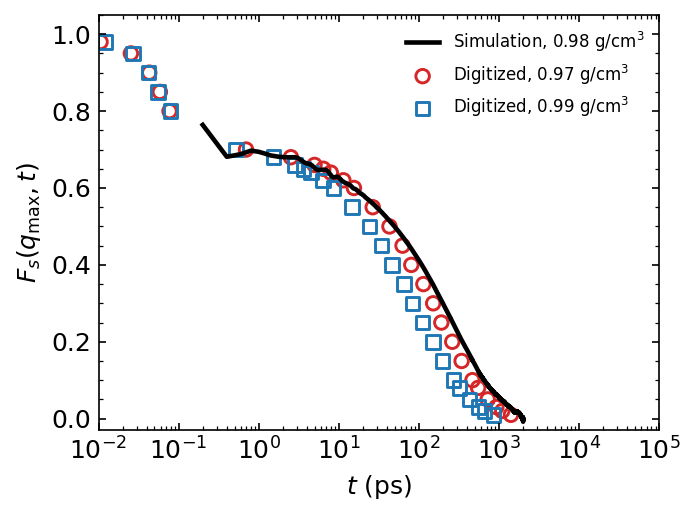

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# -----------------------------
# 1. Read digitized literature data
# -----------------------------
lit_file = "/root/SupercooledWater/data/Fs_qmax_225K_combined_0p97_0p99_long.csv"

lit = pd.read_csv(lit_file)

# 只取 225 K
lit_225 = lit[lit["T_K"] == 225].copy()

# -----------------------------
# 2. Prepare simulation data
# -----------------------------
times_ps = np.asarray(times)
sim_isf = np.asarray(isf[0])

# log 坐标不能包含 t = 0
mask_sim = (times_ps > 0) & np.isfinite(times_ps) & np.isfinite(sim_isf)

times_ps = times_ps[mask_sim]
sim_isf = sim_isf[mask_sim]

# -----------------------------
# 3. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(4.8, 3.6))

# Simulation: solid line
ax.plot(
    times_ps,
    sim_isf,
    color="black",
    lw=2.2,
    label=fr"Simulation, {0.98} g/cm$^3$"
)

# Literature digitized data: points only
markers = {
    0.97: "o",
    0.99: "s",
}

for density, group in lit_225.groupby("density_g_cm3"):
    ax.scatter(
        group["t_ps"],
        group["Fs"],
        s=42,
        marker=markers.get(density, "o"),
        facecolors="none",
        edgecolors="tab:red" if density == 0.97 else "tab:blue",
        linewidths=1.4,
        label=fr"Digitized, {density:.2f} g/cm$^3$"
    )

# -----------------------------
# 4. Axis formatting
# -----------------------------
ax.set_xscale("log")

ax.set_xlabel(r"$t$ (ps)")
ax.set_ylabel(r"$F_s(q_{\max}, t)$")

ax.set_xlim(1e-2, 1e5)
ax.set_ylim(-0.03, 1.05)

ax.tick_params(direction="in", which="both", top=True, right=True)
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.legend(
    frameon=False,
    fontsize=8,
    loc="best"
)

fig.tight_layout()
# fig.savefig("ISF_225K_simulation_vs_digitized_literature.pdf", bbox_inches="tight")
fig.savefig("ISF_225K_simulation_vs_digitized_literature.pdf")

plt.show()

/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


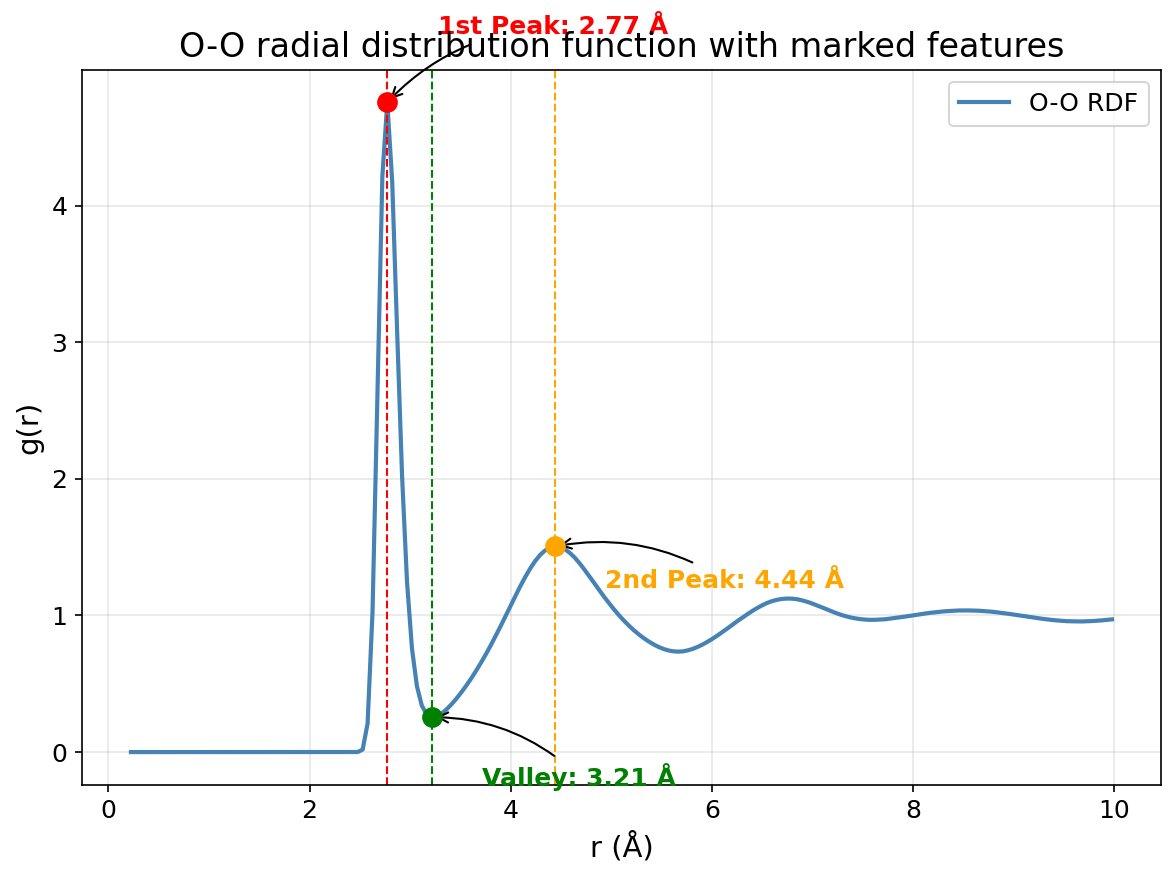

第一个峰值位置 (r): 2.7725 Å
第二个峰值位置 (r): 4.4385 Å
第一个谷底位置 (r): 3.2135 Å


In [26]:
from MDAnalysis.analysis import rdf
oxygens = u.select_atoms("type 1")

rdf_oxy = rdf.InterRDF(oxygens, oxygens, nbins=200, range=(0.2, 10.0))
rdf_oxy.run()

r = rdf_oxy.results.bins
g_r = rdf_oxy.results.rdf

from scipy.signal import find_peaks, argrelextrema

peaks, properties = find_peaks(g_r, height=1.0)

if len(peaks) > 0:
    first_peak_index = peaks[0]
    first_peak_x = r[first_peak_index]
    first_peak_y = g_r[first_peak_index]
else:
    # 备用方法（如果 find_peaks 失效）
    first_peak_index = np.argmax(g_r)
    first_peak_x = r[first_peak_index]
    first_peak_y = g_r[first_peak_index]

# 新增：检测第二个峰值
second_peak_x = None
second_peak_y = None
second_peak_index = None

if len(peaks) >= 2:
    # 如果 find_peaks 找到了至少两个峰值
    second_peak_index = peaks[1]
    second_peak_x = r[second_peak_index]
    second_peak_y = g_r[second_peak_index]
elif len(peaks) == 1:
    # 如果只找到一个峰值，尝试在第一个峰值之后寻找第二个峰值
    # 从第一个峰值之后开始搜索
    search_start = first_peak_index + 10  # 跳过第一个峰值附近的区域
    if search_start < len(g_r):
        # 在剩余部分寻找局部最大值
        remaining_g_r = g_r[search_start:]
        remaining_peaks, _ = find_peaks(remaining_g_r, height=0.8)  # 降低高度阈值
        
        if len(remaining_peaks) > 0:
            # 转换为全局索引
            second_peak_index = remaining_peaks[0] + search_start
            second_peak_x = r[second_peak_index]
            second_peak_y = g_r[second_peak_index]

# 4. 寻找第一个谷底 (First Minimum)
# 我们需要找峰值之后的局部最小值
# order=5 表示检查前后 5 个点来判断是否为极小值
minima_indices = argrelextrema(g_r, np.less, order=5)[0]

# 筛选出位于第一个峰值右侧的谷底
valley_indices = minima_indices[minima_indices > first_peak_index]

if len(valley_indices) > 0:
    first_valley_index = valley_indices[0]
    first_valley_x = r[first_valley_index]
    first_valley_y = g_r[first_valley_index]
else:
    first_valley_x = None

# 5. 绘图与标记
plt.figure(figsize=(8, 6))

# 绘制 RDF 曲线
plt.plot(r, g_r, label='O-O RDF', color='steelblue', linewidth=2)

# --- 开始标记 ---
# 标记第一个峰值
if 'first_peak_x' in locals():
    plt.axvline(first_peak_x, color='red', linestyle='--', linewidth=1)
    plt.scatter([first_peak_x], [first_peak_y], color='red', s=80, zorder=5)
    plt.annotate(f'1st Peak: {first_peak_x:.2f} Å', 
                 xy=(first_peak_x, first_peak_y), 
                 xytext=(first_peak_x + 0.5, first_peak_y + 0.5),
                 color='red',
                 fontsize=12,
                 fontweight='bold',
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'))

# 新增：标记第二个峰值
if second_peak_x is not None:
    plt.axvline(second_peak_x, color='orange', linestyle='--', linewidth=1)
    plt.scatter([second_peak_x], [second_peak_y], color='orange', s=80, zorder=5)
    plt.annotate(f'2nd Peak: {second_peak_x:.2f} Å', 
                 xy=(second_peak_x, second_peak_y), 
                 xytext=(second_peak_x + 0.5, second_peak_y - 0.3),
                 color='orange',
                 fontsize=12,
                 fontweight='bold',
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'))

# 标记第一个谷底
if first_valley_x is not None:
    plt.axvline(first_valley_x, color='green', linestyle='--', linewidth=1)
    plt.scatter([first_valley_x], [first_valley_y], color='green', s=80, zorder=5)
    plt.annotate(f'Valley: {first_valley_x:.2f} Å', 
                 xy=(first_valley_x, first_valley_y), 
                 xytext=(first_valley_x + 0.5, first_valley_y - 0.5),
                 color='green',
                 fontsize=12,
                 fontweight='bold',
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'))

# --- 美化图表 ---
plt.xlabel("r (Å)", fontsize=14)
plt.ylabel("g(r)", fontsize=14)
plt.title("O-O radial distribution function with marked features", fontsize=16)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 打印结果到控制台
print(f"第一个峰值位置 (r): {first_peak_x:.4f} Å")
if second_peak_x is not None:
    print(f"第二个峰值位置 (r): {second_peak_x:.4f} Å")
else:
    print("未检测到第二个峰值")
if first_valley_x is not None:
    print(f"第一个谷底位置 (r): {first_valley_x:.4f} Å")
else:
    print("未检测到谷底")

Successfully read file with encoding: latin1
       T    r1  rmin    r2        g1      gmin        g2
4  234.8  2.76  3.37  4.49  3.185983  0.408893  1.405204
3  240.9  2.78  3.33  4.47  3.009013  0.531180  1.349674
2  243.8  2.78  3.34  4.49  2.951254  0.571163  1.310403
1  247.7  2.79  3.33  4.47  2.899414  0.587626  1.289124
0  264.0  2.80  3.37  4.45  2.761727  0.708144  1.218724


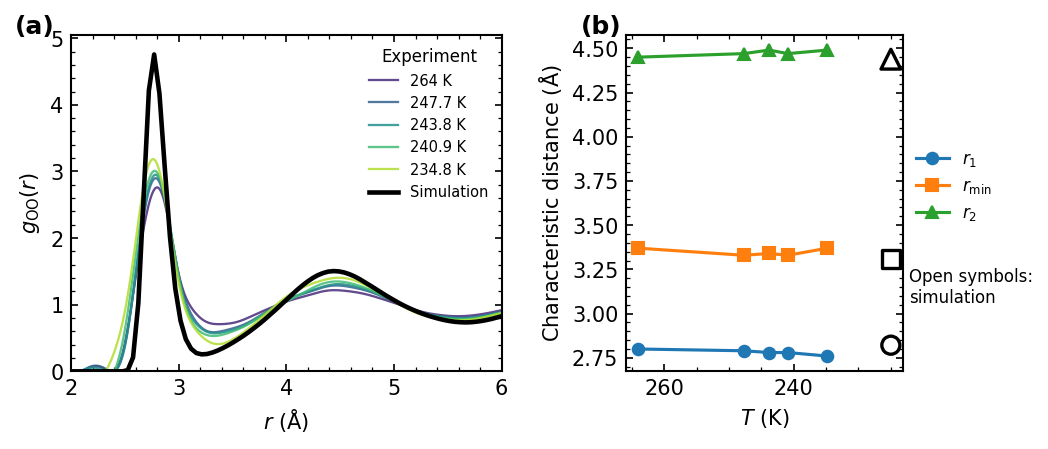

In [27]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.ticker import AutoMinorLocator

# -----------------------------
# 1. Read experimental data
# -----------------------------
exp_file = "/root/SupercooledWater/data/Calculated pdf_GOO.txt"

# Try several encodings
for enc in ["utf-8-sig", "latin1", "cp1252", "gbk"]:
    try:
        exp = pd.read_csv(exp_file, skiprows=2, encoding=enc)
        print(f"Successfully read file with encoding: {enc}")
        break
    except UnicodeDecodeError:
        pass

exp = exp.rename(columns={exp.columns[0]: "r"})

r_exp = exp["r"].values
exp_cols = [c for c in exp.columns if c.startswith("GOO_")]

# Extract temperature from column names
def get_temperature(col):
    match = re.search(r"GOO_([\d.]+)K", col)
    return float(match.group(1))

exp_cols = sorted(exp_cols, key=get_temperature, reverse=True)
temps = np.array([get_temperature(c) for c in exp_cols])

# -----------------------------
# 2. Simulation RDF
# -----------------------------
r_sim = np.asarray(rdf_oxy.results.bins)
g_sim = np.asarray(rdf_oxy.results.rdf)

# -----------------------------
# 3. Feature extraction function
# -----------------------------
def extract_rdf_features(r, g, smooth=True):
    r = np.asarray(r)
    g = np.asarray(g)

    if smooth and len(g) > 21:
        g_for_feature = savgol_filter(g, window_length=21, polyorder=3)
    else:
        g_for_feature = g.copy()

    # First O-O peak
    mask1 = (r >= 2.3) & (r <= 3.2)
    i1 = np.where(mask1)[0][np.argmax(g_for_feature[mask1])]

    # First minimum
    mask_min = (r > r[i1]) & (r <= 3.8)
    imin = np.where(mask_min)[0][np.argmin(g_for_feature[mask_min])]

    # Second peak
    mask2 = (r >= 3.8) & (r <= 5.2)
    i2 = np.where(mask2)[0][np.argmax(g_for_feature[mask2])]

    return {
        "r1": r[i1],
        "g1": g[i1],
        "rmin": r[imin],
        "gmin": g[imin],
        "r2": r[i2],
        "g2": g[i2],
    }

# Simulation features
sim_features = extract_rdf_features(r_sim, g_sim)

# Experimental features
feature_rows = []

for col in exp_cols:
    T = get_temperature(col)
    g_exp = exp[col].values
    f = extract_rdf_features(r_exp, g_exp)
    feature_rows.append({
        "T": T,
        "r1": f["r1"],
        "rmin": f["rmin"],
        "r2": f["r2"],
        "g1": f["g1"],
        "gmin": f["gmin"],
        "g2": f["g2"],
    })

feature_df = pd.DataFrame(feature_rows).sort_values("T")

print(feature_df)

# -----------------------------
# 4. Plot settings
# -----------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "figure.dpi": 150
})

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(7.4, 3.3),
    gridspec_kw={"width_ratios": [1.55, 1.0]}
)

# -----------------------------
# 5. Panel a: RDF comparison
# -----------------------------
colors = plt.cm.viridis(np.linspace(0.12, 0.88, len(exp_cols)))

for col, color in zip(exp_cols, colors):
    T = get_temperature(col)
    ax1.plot(
        r_exp,
        exp[col],
        lw=1.1,
        color=color,
        alpha=0.85,
        label=f"{T:g} K"
    )

ax1.plot(
    r_sim,
    g_sim,
    color="black",
    lw=2.2,
    label="Simulation",
    zorder=5
)

# Mark simulation features
feature_marks = [
    ("r1", "g1", "1st peak", "crimson"),
    ("rmin", "gmin", "1st minimum", "seagreen"),
    ("r2", "g2", "2nd peak", "darkorange"),
]

text_y = {
    "r1": 1.05,
    "rmin": 1.15,
    "r2": 1.05,
}

# for rx, gy, label, color in feature_marks:
#     x = sim_features[rx]
#     y = sim_features[gy]

#     ax1.axvline(
#         x,
#         color=color,
#         ls="--",
#         lw=1.0,
#         alpha=0.75,
#         zorder=1
#     )

#     ax1.scatter(
#         x,
#         y,
#         s=42,
#         color=color,
#         edgecolor="white",
#         linewidth=0.8,
#         zorder=10
#     )

#     ax1.text(
#         x,
#         text_y[rx],
#         f"{label}\n{x:.2f} Å",
#         color=color,
#         ha="center",
#         va="bottom",
#         fontsize=8,
#         fontweight="bold",
#         transform=ax1.get_xaxis_transform(),
#         clip_on=False
#     )

ax1.set_xlim(2.0, 6.0)
ax1.set_ylim(0.0, None)

ax1.set_xlabel(r"$r$ ($\mathrm{\AA}$)")
ax1.set_ylabel(r"$g_{\mathrm{OO}}(r)$")

ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())

ax1.legend(
    frameon=False,
    fontsize=7,
    loc="upper right",
    title="Experiment",
    title_fontsize=8
)

ax1.text(
    -0.13, 1.06,
    "(a)",
    transform=ax1.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top"
)

# -----------------------------
# 6. Panel b: extracted feature positions
# -----------------------------
# -----------------------------
# 6. Panel b: extracted feature positions
# -----------------------------

# Experimental data: filled symbols with lines
ax2.plot(
    feature_df["T"],
    feature_df["r1"],
    marker="o",
    lw=1.5,
    markersize=5.5,
    label=r"$r_1$"
)

ax2.plot(
    feature_df["T"],
    feature_df["rmin"],
    marker="s",
    lw=1.5,
    markersize=5.5,
    label=r"$r_{\min}$"
)

ax2.plot(
    feature_df["T"],
    feature_df["r2"],
    marker="^",
    lw=1.5,
    markersize=6.0,
    label=r"$r_2$"
)

# -----------------------------
# Simulation data: open symbols
# -----------------------------
T_sim = 225.0  # 改成你的模拟温度；也可以稍微偏移避免重合

ax2.scatter(
    T_sim,
    sim_features["r1"],
    marker="o",
    s=75,
    facecolors="none",
    edgecolors="black",
    linewidths=1.6,
    zorder=6
)

ax2.scatter(
    T_sim,
    sim_features["rmin"],
    marker="s",
    s=75,
    facecolors="none",
    edgecolors="black",
    linewidths=1.6,
    zorder=6
)

ax2.scatter(
    T_sim,
    sim_features["r2"],
    marker="^",
    s=90,
    facecolors="none",
    edgecolors="black",
    linewidths=1.6,
    zorder=6
)

# Axis labels
ax2.set_xlabel(r"$T$ (K)")
ax2.set_ylabel(r"Characteristic distance ($\mathrm{\AA}$)")

# Cooling direction from left to right
ax2.invert_xaxis()

ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())

# -----------------------------
# Move legend outside the data region
# -----------------------------
ax2.legend(
    frameon=False,
    fontsize=8,
    loc="center left",
    bbox_to_anchor=(1.02, 0.55),
    borderaxespad=0.0,
    handlelength=2.0
)

# Add concise note for simulation symbols
ax2.text(
    1.02,
    0.25,
    "Open symbols:\nsimulation",
    transform=ax2.transAxes,
    fontsize=8,
    ha="left",
    va="center"
)

# Panel label
ax2.text(
    -0.16,
    1.06,
    "(b)",
    transform=ax2.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top"
)

# -----------------------------
# 7. Save figure
# -----------------------------
fig.subplots_adjust(
    top=0.84,
    bottom=0.16,
    left=0.09,
    right=0.84,
    wspace=0.35
)

# fig.savefig("GOO_RDF_two_panel.pdf", bbox_inches="tight")
fig.savefig("GOO_RDF_two_panel.pdf")

plt.show()

In [28]:
from tools.msd import MSDCalculator

In [29]:
msdcal = MSDCalculator(u)
msd0 = msdcal.time_origin_average(idx=0)

times = np.arange(len(msd0)) * 0.2

msd = msd0 * 1e-2

Loading trajectory data:   0%|          | 0/10001 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt
Computing MSD time-origin average: 100%|██████████| 10001/10001 [14:34<00:00, 11.44it/s] 


In [43]:
from MDAnalysis.analysis.msd import EinsteinMSD

In [44]:
MSD = EinsteinMSD(u, select='type 1', msd_type='xyz', fft=True)
MSD.run()

/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt
100%|██████████| 4096/4096 [00:23<00:00, 173.62it/s]


In [45]:
lagtimes = MSD.results.delta_t_values
msd = MSD.results.timeseries

msd *= 1e-2
times = lagtimes * 0.2

In [46]:
print(u.trajectory.dt)

1.0


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/base.py:730: UserWarning: Reader has no dt information, set to 1.0 ps
  return self.ts.dt


In [34]:
times = np.arange(len(msd0)) * 0.2

In [48]:
times = lagtimes * 0.005

In [22]:
print(times)

[0.000e+00 1.000e+00 2.000e+00 ... 9.998e+03 9.999e+03 1.000e+04]


/tmp/ipykernel_3241999/3927031125.py:81: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.tight_layout()
/tmp/ipykernel_3241999/3927031125.py:83: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.savefig("MSD_225K_simulation_vs_digitized_literature.pdf")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


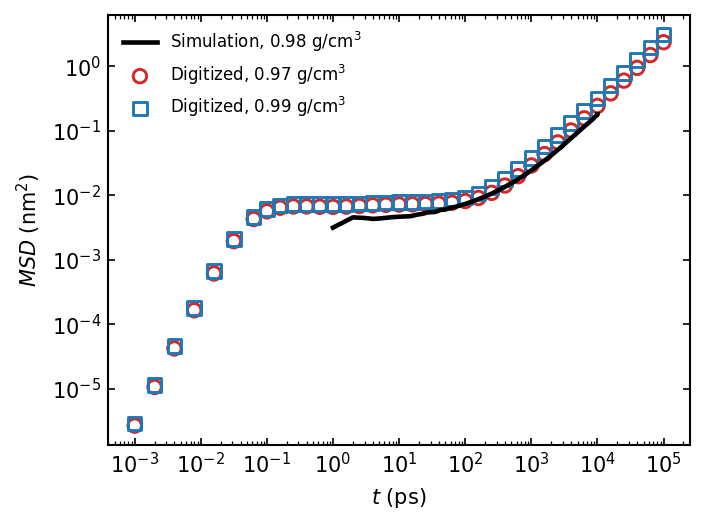

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# -----------------------------
# 1. Read digitized literature data
# -----------------------------
lit_file = "/root/SupercooledWater/data/MSD_225K_digitized_0p97_0p99_long.csv"

lit = pd.read_csv(lit_file)

# 只取 225 K
lit_225 = lit[lit["T_K"] == 225].copy()

# -----------------------------
# 2. Prepare simulation data
# -----------------------------
times_ps = np.asarray(times)
sim_msd = np.asarray(msd)

# log 坐标不能包含 t = 0
mask_sim = (times_ps > 0) & np.isfinite(times_ps) & np.isfinite(sim_msd)

times_ps = times_ps[mask_sim]
sim_msd = sim_msd[mask_sim]

# -----------------------------
# 3. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(4.8, 3.6))

# Simulation: solid line
ax.plot(
    times_ps,
    sim_msd,
    color="black",
    lw=2.2,
    label=fr"Simulation, {0.98} g/cm$^3$"
)

# Literature digitized data: points only
markers = {
    0.97: "o",
    0.99: "s",
}

for density, group in lit_225.groupby("density_g_cm3"):
    ax.scatter(
        group["t_ps"],
        group["MSD_nm2"],
        s=42,
        marker=markers.get(density, "o"),
        facecolors="none",
        edgecolors="tab:red" if density == 0.97 else "tab:blue",
        linewidths=1.4,
        label=fr"Digitized, {density:.2f} g/cm$^3$"
    )

# -----------------------------
# 4. Axis formatting
# -----------------------------
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$t$ (ps)")
ax.set_ylabel(r"$MSD$ (nm$^2$)")

# ax.set_xlim(1e-2, 1e5)
# ax.set_ylim(-0.03, 1.05)

ax.tick_params(direction="in", which="both", top=True, right=True)
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.legend(
    frameon=False,
    fontsize=8,
    loc="best"
)

fig.tight_layout()
# fig.savefig("ISF_225K_simulation_vs_digitized_literature.pdf", bbox_inches="tight")
fig.savefig("MSD_225K_simulation_vs_digitized_literature.pdf")

plt.show()

In [32]:
from scipy.stats import linregress
start_time = 500

mask = times_ps > start_time

linear_model = linregress(np.log10(times_ps[mask]), np.log10(sim_msd[mask]))
slope = linear_model.slope
error = linear_model.stderr
# dim_fac is 3 as we computed a 3D msd with 'xyz'
D = slope * 1/(2*MSD.dim_fac)

In [34]:
print(1/D)

6.961792610445675


In [24]:
from MDAnalysis.lib.distances import capped_distance, minimize_vectors


def build_water_mapping(u, oxygen_sel="type 1", hydrogen_sel="type 2"):
    """
    Build the mapping:
        O_i -> [H_i1, H_i2]

    The function first tries to use residue/molecule labels.
    If this fails, it falls back to the common O-H-H atom ordering.
    """

    O = u.select_atoms(oxygen_sel)
    H = u.select_atoms(hydrogen_sel)

    if len(H) != 2 * len(O):
        raise ValueError(
            f"Hydrogen number is not twice oxygen number: "
            f"nO={len(O)}, nH={len(H)}"
        )

    # ---------- Method 1: use molecule/residue labels ----------
    for attr in ["molnums", "resids", "resnums"]:
        try:
            O_labels = np.asarray(getattr(O, attr))
            H_labels = np.asarray(getattr(H, attr))
        except Exception:
            continue

        # Need one oxygen per water molecule
        if len(np.unique(O_labels)) != len(O_labels):
            continue

        H_pair_indices = []
        ok = True

        for label in O_labels:
            h_local = np.where(H_labels == label)[0]

            if len(h_local) != 2:
                ok = False
                break

            # Sort the two hydrogens by atom id for reproducibility
            h_atoms = H[h_local]
            order = np.argsort(h_atoms.ids)
            H_pair_indices.append(h_atoms.indices[order])

        if ok:
            return O.indices.copy(), np.asarray(H_pair_indices, dtype=int)

    # ---------- Method 2: fallback to O-H-H ordering ----------
    all_atoms = u.atoms[np.argsort(u.atoms.ids)]

    O_set = set(O.indices.tolist())
    H_set = set(H.indices.tolist())

    O_indices = []
    H_pair_indices = []

    for k in range(0, len(all_atoms), 3):
        triplet = all_atoms[k:k+3]

        if len(triplet) < 3:
            continue

        o_candidates = [a.index for a in triplet if a.index in O_set]
        h_candidates = [a.index for a in triplet if a.index in H_set]

        if len(o_candidates) == 1 and len(h_candidates) == 2:
            O_indices.append(o_candidates[0])
            H_pair_indices.append(h_candidates)

    if len(O_indices) == len(O):
        return np.asarray(O_indices, dtype=int), np.asarray(H_pair_indices, dtype=int)

    raise RuntimeError(
        "Failed to build O-H-H water mapping. "
        "Please check whether molecule IDs/resids exist, or whether atoms follow O-H-H ordering."
    )


def compute_r_theta_one_frame(
    u,
    O_indices,
    H_pair_indices,
    cutoff=6.0,          # Å
):
    """
    Compute r and theta for one frame.
    theta = min of FOUR H-O-O angles (paper definition).

    Returns
    -------
    r : ndarray (nm)
    theta : ndarray (degrees)
    pairs : ndarray
    """

    box = u.trajectory.ts.dimensions.copy()

    O_pos = u.atoms[O_indices].positions.astype(np.float64)
    H_pos = (
        u.atoms[H_pair_indices.reshape(-1)]
        .positions.astype(np.float64)
        .reshape(len(O_indices), 2, 3)
    )

    pairs, dist_A = capped_distance(
        O_pos, O_pos,
        max_cutoff=cutoff,
        box=box,
        return_distances=True,
    )

    mask = dist_A > 1e-8
    pairs = pairs[mask]
    dist_A = dist_A[mask]

    if len(pairs) == 0:
        return np.array([]), np.array([]), pairs

    i = pairs[:, 0]
    j = pairs[:, 1]

    # --- vectors ---
    vec_OO = minimize_vectors(O_pos[j] - O_pos[i], box=box)
    vec_OO_rev = minimize_vectors(O_pos[i] - O_pos[j], box=box)

    vec_OH_i1 = minimize_vectors(H_pos[i, 0] - O_pos[i], box=box)
    vec_OH_i2 = minimize_vectors(H_pos[i, 1] - O_pos[i], box=box)
    vec_OH_j1 = minimize_vectors(H_pos[j, 0] - O_pos[j], box=box)
    vec_OH_j2 = minimize_vectors(H_pos[j, 1] - O_pos[j], box=box)

    # --- angle helper ---
    def angle(v1, v2):
        v1 /= np.linalg.norm(v1, axis=1, keepdims=True)
        v2 /= np.linalg.norm(v2, axis=1, keepdims=True)
        cosang = np.einsum("ij,ij->i", v1, v2)
        cosang = np.clip(cosang, -1.0, 1.0)
        return np.degrees(np.arccos(cosang))

    # --- FOUR angles ---
    t1 = angle(vec_OH_i1, vec_OO)
    t2 = angle(vec_OH_i2, vec_OO)
    t3 = angle(vec_OH_j1, vec_OO_rev)
    t4 = angle(vec_OH_j2, vec_OO_rev)

    theta = np.minimum.reduce([t1, t2, t3, t4])

    r = dist_A

    return r, theta, pairs

def compute_joint_distribution(
    u,
    oxygen_sel="type 1",
    hydrogen_sel="type 2",
    cutoff=6.0,
    start=None,
    stop=None,
    step=None,
    r_bin_width=0.05,
    theta_bin_width=1.0,
    theta_mode="min",
):
    """
    Compute the joint distribution P(r, theta) by streaming over frames.

    Returns
    -------
    P : ndarray
        Normalized probability density.
        Shape: (n_r_bins, n_theta_bins)
    counts : ndarray
        Raw histogram counts.
    r_edges : ndarray
        Bin edges for r.
    theta_edges : ndarray
        Bin edges for theta.
    """

    O_indices, H_pair_indices = build_water_mapping(
        u,
        oxygen_sel=oxygen_sel,
        hydrogen_sel=hydrogen_sel,
    )

    r_edges = np.arange(0.0, cutoff + r_bin_width, r_bin_width)
    theta_edges = np.arange(0.0, 180.0 + theta_bin_width, theta_bin_width)

    counts = np.zeros((len(r_edges) - 1, len(theta_edges) - 1), dtype=np.float64)

    for ts in u.trajectory[start:stop:step]:
        r, theta, pairs = compute_r_theta_one_frame(
            u,
            O_indices,
            H_pair_indices,
            cutoff=cutoff,
        )

        hist, _, _ = np.histogram2d(
            r,
            theta,
            bins=[r_edges, theta_edges],
        )

        counts += hist

    # Convert raw counts into probability density P(r, theta)
    dr = np.diff(r_edges)
    dtheta = np.diff(theta_edges)

    if counts.sum() > 0:
        P = counts / counts.sum()
        P = P / (dr[:, None] * dtheta[None, :])
    else:
        P = counts.copy()

    return P, counts, r_edges, theta_edges


def plot_joint_distribution(
    P,
    r_edges,
    theta_edges,
    log_scale=True,
    title=None,
):
    """
    Plot P(r, theta) with r as x-axis and theta as y-axis.
    """

    if log_scale:
        Z = np.log10(P.T + 1e-12)
        cbar_label = r"$\log_{10} P(r,\theta)$"
    else:
        Z = P.T
        cbar_label = r"$P(r,\theta)$"

    fig, ax = plt.subplots(figsize=(6.5, 5.0))

    im = ax.imshow(
        Z,
        origin="lower",
        aspect="auto",
        extent=[
            r_edges[0],
            r_edges[-1],
            theta_edges[0],
            theta_edges[-1],
        ],
        interpolation="nearest",
    )

    ax.set_xlabel(r"$r_{\mathrm{OO}}$ ($\AA$)")
    ax.set_ylabel(r"$\theta$ (degree)")
    ax.set_ylim(0,100)

    # if title is None:
    #     title = r"Joint orientational-distance distribution $P(r,\theta)$"

    ax.set_title(title)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    plt.tight_layout()
    plt.savefig("theta_vs_r.pdf")
    plt.show()

In [22]:
P, counts, r_edges, theta_edges = compute_joint_distribution(
    u,
    oxygen_sel="type 1",
    hydrogen_sel="type 2",
    cutoff=6.0,
    start=0,
    stop=200,
    step=5,
    r_bin_width=0.05,
    theta_bin_width=1.0,
)

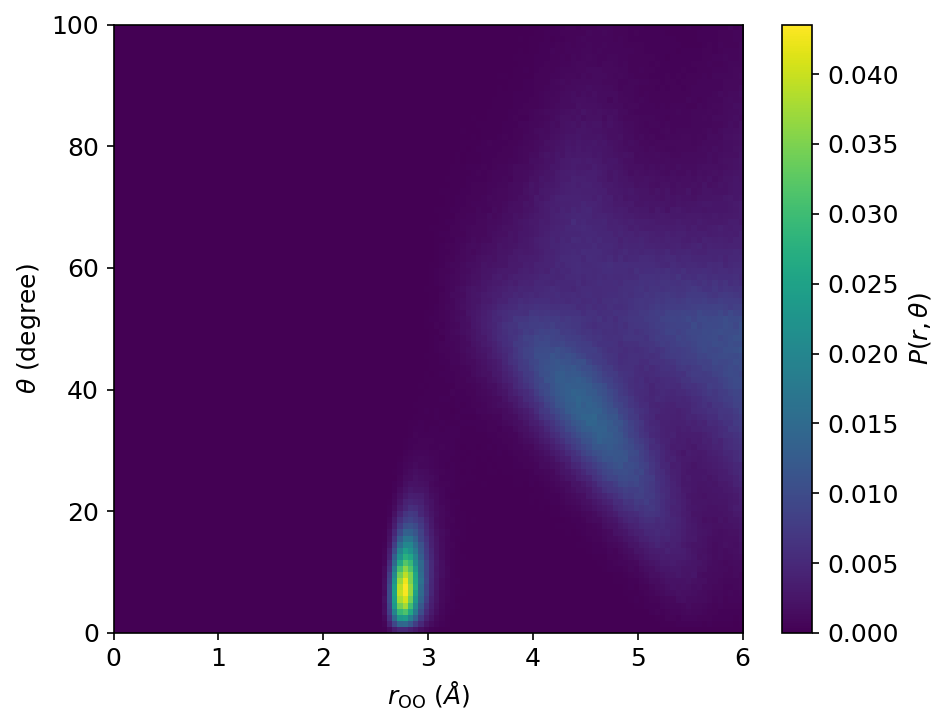

In [25]:
plot_joint_distribution(
    P,
    r_edges,
    theta_edges,
    log_scale=False,
)

In [4]:
hba = HBA(
    universe=u,
    donors_sel="type 1",
    hydrogens_sel="type 2",
    acceptors_sel="type 1",
    d_a_cutoff=3.5,          # Å – donor-to-acceptor heavy-atom distance
    h_d_a_angle_cutoff=30.0, # °  – angle at the donor (H-D-A < 30°)
    update_selections=False, # Set True for flexible / protein systems
)

# ---- Run --------------------------------------------------------------------
# start/stop/step follow MDAnalysis convention (frame indices, not time).
# Omit them to analyse every frame.
hba.run()

/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


In [5]:
zop = ZOP(
    hba=hba,
    central_sel="type 1",
    shell_cutoff=6.0,
)
zop.run(verbose=True)
 
times_ps        = zop.results.times          # shape (n_frames,)
central_indices = zop.results.central_indices  # OW atom indices

  0%|          | 0/10001 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt
100%|██████████| 10001/10001 [32:08<00:00,  5.18it/s]
/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/base.py:730: UserWarning: Reader has no dt information, set to 1.0 ps
  return self.ts.dt


Text(0.5, 0, '$\\zeta$\\text{AA}')

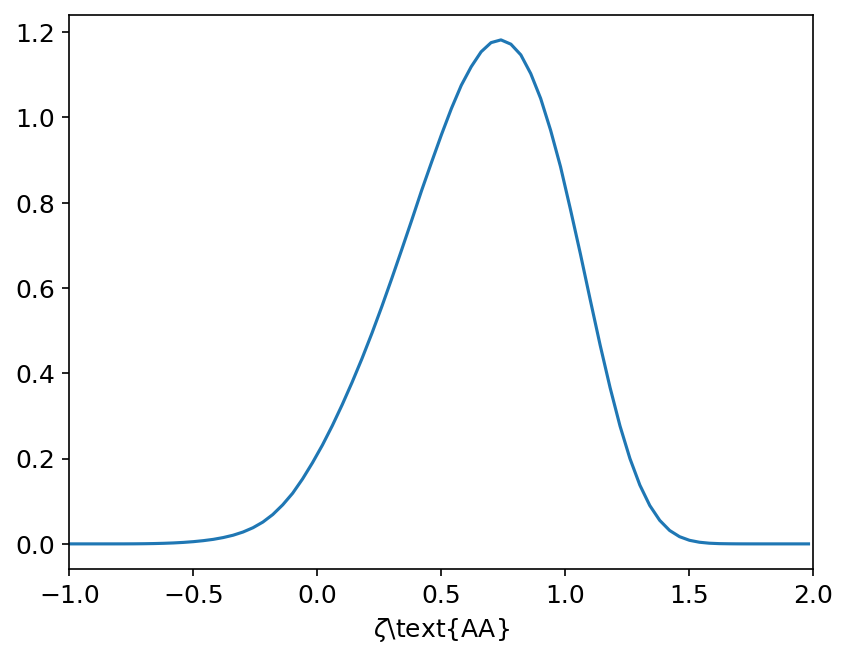

In [ ]:
center, counts = zop.get_zeta_distribution()
plt.plot(center, counts)
plt.xlim(-1.0, 2.0)
plt.xlabel(r"$\zeta$\text{\AA}")

Mean HB number per molecule: 3.9582020801826068
Std: 0.3423306993824529
Min / Max: 0 7


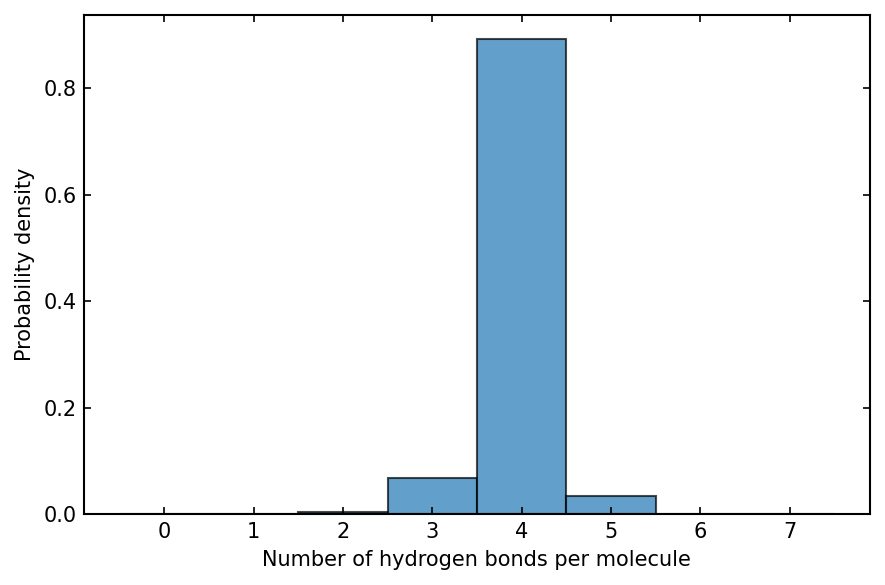

: 

In [ ]:
hbonds = hba.results.hbonds

# 只保留 frame, donor, acceptor
# 如果一个 donor-acceptor pair 在同一帧因为两个 H 被重复识别，可以先去重
hba_DA = hbonds[:, [0, 1, 3]].astype(int)
hba_DA = np.unique(hba_DA, axis=0)

frames = hba_DA[:, 0]
donors = hba_DA[:, 1]
acceptors = hba_DA[:, 2]

# Oxygen atoms
O_atoms = u.select_atoms("type 1")
O_indices = O_atoms.indices
n_O = len(O_indices)

# atom index -> local water index
atom_to_local = {atom_idx: i for i, atom_idx in enumerate(O_indices)}

n_frames = len(u.trajectory)

hb_count_per_molecule = np.zeros((n_frames, n_O), dtype=np.int16)

for f, d, a in zip(frames, donors, acceptors):
    if d in atom_to_local:
        hb_count_per_molecule[f, atom_to_local[d]] += 1
    if a in atom_to_local:
        hb_count_per_molecule[f, atom_to_local[a]] += 1

# 把所有帧、所有水分子的氢键数拉平成一维分布
hb_count_flat = hb_count_per_molecule.ravel()

print("Mean HB number per molecule:", hb_count_flat.mean())
print("Std:", hb_count_flat.std())
print("Min / Max:", hb_count_flat.min(), hb_count_flat.max())

plt.figure(figsize=(6, 4))
bins = np.arange(hb_count_flat.max() + 2) - 0.5

plt.hist(
    hb_count_flat,
    bins=bins,
    density=True,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Number of hydrogen bonds per molecule")
plt.ylabel("Probability density")
# plt.title("Distribution of molecular hydrogen-bond number")
plt.xticks(np.arange(hb_count_flat.max() + 1))
plt.tight_layout()
plt.savefig("hbond_distribution.pdf")
plt.show()

Mean HB number per molecule: 3.8751856225396777
Std: 0.5354167779620557
Min / Max: 0 7


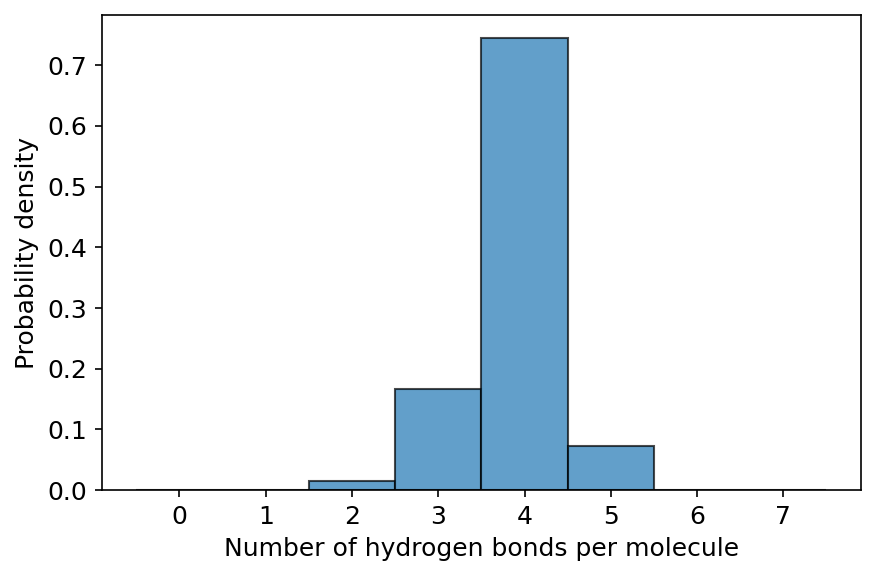

In [3]:
u = mda.Universe(traj("tip4p-ice-225K.data"), traj("traj_1e-4_225_100000.lammpstrj"), format="LAMMPSDUMP", dt=0.001)

hba = HBA(
    universe=u,
    donors_sel="type 1",
    hydrogens_sel="type 2",
    acceptors_sel="type 1",
    d_a_cutoff=3.5,          # Å – donor-to-acceptor heavy-atom distance
    h_d_a_angle_cutoff=30.0, # °  – angle at the donor (H-D-A < 30°)
    update_selections=False, # Set True for flexible / protein systems
)

# ---- Run --------------------------------------------------------------------
# start/stop/step follow MDAnalysis convention (frame indices, not time).
# Omit them to analyse every frame.
hba.run()
hbonds = hba.results.hbonds

# 只保留 frame, donor, acceptor
# 如果一个 donor-acceptor pair 在同一帧因为两个 H 被重复识别，可以先去重
hba_DA = hbonds[:, [0, 1, 3]].astype(int)
hba_DA = np.unique(hba_DA, axis=0)

frames = hba_DA[:, 0]
donors = hba_DA[:, 1]
acceptors = hba_DA[:, 2]

# Oxygen atoms
O_atoms = u.select_atoms("type 1")
O_indices = O_atoms.indices
n_O = len(O_indices)

# atom index -> local water index
atom_to_local = {atom_idx: i for i, atom_idx in enumerate(O_indices)}

n_frames = len(u.trajectory)

hb_count_per_molecule = np.zeros((n_frames, n_O), dtype=np.int16)

for f, d, a in zip(frames, donors, acceptors):
    if d in atom_to_local:
        hb_count_per_molecule[f, atom_to_local[d]] += 1
    if a in atom_to_local:
        hb_count_per_molecule[f, atom_to_local[a]] += 1

# 把所有帧、所有水分子的氢键数拉平成一维分布
hb_count_flat = hb_count_per_molecule.ravel()

print("Mean HB number per molecule:", hb_count_flat.mean())
print("Std:", hb_count_flat.std())
print("Min / Max:", hb_count_flat.min(), hb_count_flat.max())

plt.figure(figsize=(6, 4))
bins = np.arange(hb_count_flat.max() + 2) - 0.5

plt.hist(
    hb_count_flat,
    bins=bins,
    density=True,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Number of hydrogen bonds per molecule")
plt.ylabel("Probability density")
# plt.title("Distribution of molecular hydrogen-bond number")
plt.xticks(np.arange(hb_count_flat.max() + 1))
plt.tight_layout()
plt.savefig("hbond_distribution_1e_4.pdf")
plt.show()

Mean HB number per molecule: 3.8858700416926433
Std: 0.5449257355469638
Min / Max: 1 7


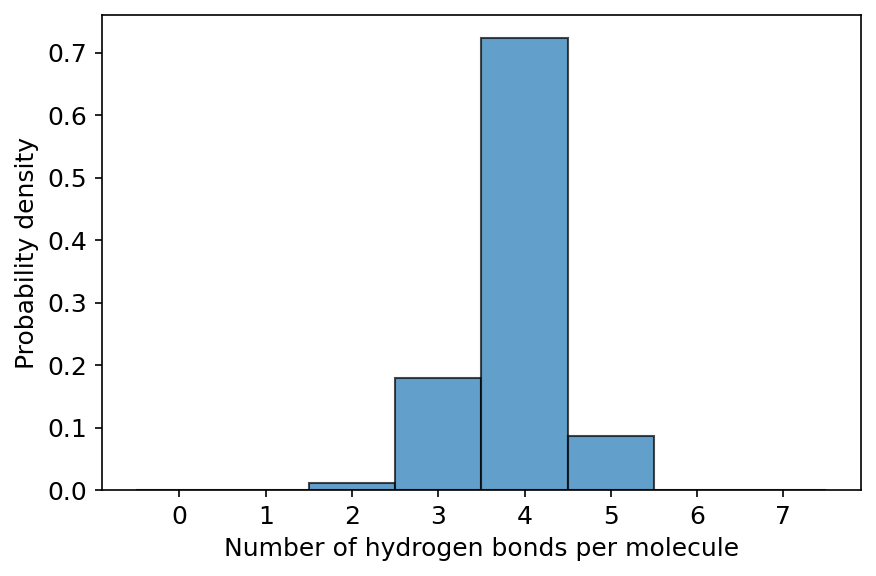

In [5]:
u = mda.Universe(traj("tip4p-ice-225K.data"), traj("traj_3e-4_225_10000.lammpstrj"), format="LAMMPSDUMP", dt=0.001)

hba = HBA(
    universe=u,
    donors_sel="type 1",
    hydrogens_sel="type 2",
    acceptors_sel="type 1",
    d_a_cutoff=3.5,          # Å – donor-to-acceptor heavy-atom distance
    h_d_a_angle_cutoff=30.0, # °  – angle at the donor (H-D-A < 30°)
    update_selections=False, # Set True for flexible / protein systems
)

# ---- Run --------------------------------------------------------------------
# start/stop/step follow MDAnalysis convention (frame indices, not time).
# Omit them to analyse every frame.
hba.run()
hbonds = hba.results.hbonds

# 只保留 frame, donor, acceptor
# 如果一个 donor-acceptor pair 在同一帧因为两个 H 被重复识别，可以先去重
hba_DA = hbonds[:, [0, 1, 3]].astype(int)
hba_DA = np.unique(hba_DA, axis=0)

frames = hba_DA[:, 0]
donors = hba_DA[:, 1]
acceptors = hba_DA[:, 2]

# Oxygen atoms
O_atoms = u.select_atoms("type 1")
O_indices = O_atoms.indices
n_O = len(O_indices)

# atom index -> local water index
atom_to_local = {atom_idx: i for i, atom_idx in enumerate(O_indices)}

n_frames = len(u.trajectory)

hb_count_per_molecule = np.zeros((n_frames, n_O), dtype=np.int16)

for f, d, a in zip(frames, donors, acceptors):
    if d in atom_to_local:
        hb_count_per_molecule[f, atom_to_local[d]] += 1
    if a in atom_to_local:
        hb_count_per_molecule[f, atom_to_local[a]] += 1

# 把所有帧、所有水分子的氢键数拉平成一维分布
hb_count_flat = hb_count_per_molecule.ravel()

print("Mean HB number per molecule:", hb_count_flat.mean())
print("Std:", hb_count_flat.std())
print("Min / Max:", hb_count_flat.min(), hb_count_flat.max())

plt.figure(figsize=(6, 4))
bins = np.arange(hb_count_flat.max() + 2) - 0.5

plt.hist(
    hb_count_flat,
    bins=bins,
    density=True,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Number of hydrogen bonds per molecule")
plt.ylabel("Probability density")
# plt.title("Distribution of molecular hydrogen-bond number")
plt.xticks(np.arange(hb_count_flat.max() + 1))
plt.tight_layout()
plt.savefig("hbond_distribution_3e_4.pdf")
plt.show()

Mean HB number per molecule: 3.929226555665771
Std: 0.42724649721054725
Min / Max: 0 7


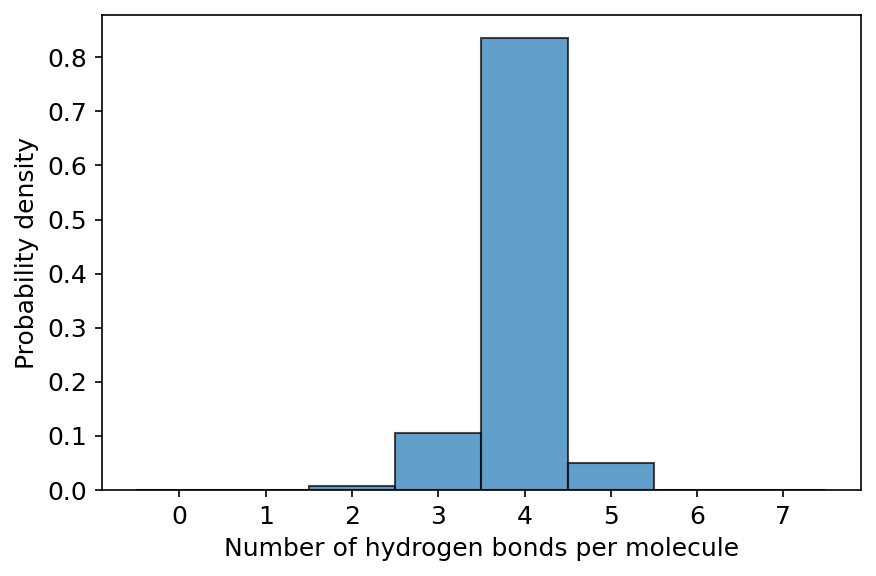

In [7]:
u = mda.Universe(traj("tip4p-ice-225K.data"), traj("traj_1e-5_225_100000.lammpstrj"), format="LAMMPSDUMP", dt=0.001)

hba = HBA(
    universe=u,
    donors_sel="type 1",
    hydrogens_sel="type 2",
    acceptors_sel="type 1",
    d_a_cutoff=3.5,          # Å – donor-to-acceptor heavy-atom distance
    h_d_a_angle_cutoff=30.0, # °  – angle at the donor (H-D-A < 30°)
    update_selections=False, # Set True for flexible / protein systems
)

# ---- Run --------------------------------------------------------------------
# start/stop/step follow MDAnalysis convention (frame indices, not time).
# Omit them to analyse every frame.
hba.run()
hbonds = hba.results.hbonds

# 只保留 frame, donor, acceptor
# 如果一个 donor-acceptor pair 在同一帧因为两个 H 被重复识别，可以先去重
hba_DA = hbonds[:, [0, 1, 3]].astype(int)
hba_DA = np.unique(hba_DA, axis=0)

frames = hba_DA[:, 0]
donors = hba_DA[:, 1]
acceptors = hba_DA[:, 2]

# Oxygen atoms
O_atoms = u.select_atoms("type 1")
O_indices = O_atoms.indices
n_O = len(O_indices)

# atom index -> local water index
atom_to_local = {atom_idx: i for i, atom_idx in enumerate(O_indices)}

n_frames = len(u.trajectory)

hb_count_per_molecule = np.zeros((n_frames, n_O), dtype=np.int16)

for f, d, a in zip(frames, donors, acceptors):
    if d in atom_to_local:
        hb_count_per_molecule[f, atom_to_local[d]] += 1
    if a in atom_to_local:
        hb_count_per_molecule[f, atom_to_local[a]] += 1

# 把所有帧、所有水分子的氢键数拉平成一维分布
hb_count_flat = hb_count_per_molecule.ravel()

print("Mean HB number per molecule:", hb_count_flat.mean())
print("Std:", hb_count_flat.std())
print("Min / Max:", hb_count_flat.min(), hb_count_flat.max())

plt.figure(figsize=(6, 4))
bins = np.arange(hb_count_flat.max() + 2) - 0.5

plt.hist(
    hb_count_flat,
    bins=bins,
    density=True,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Number of hydrogen bonds per molecule")
plt.ylabel("Probability density")
# plt.title("Distribution of molecular hydrogen-bond number")
plt.xticks(np.arange(hb_count_flat.max() + 1))
plt.tight_layout()
plt.savefig("hbond_distribution_1e_5.pdf")
plt.show()